In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# import nltk
# nltk.download('popular', quiet=True)
# import re
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# lemmatizer = WordNetLemmatizer()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
training_data = pd.read_csv('../data/intent_training_data.csv')
training_data.head()

,question,label
0,How has unemployment changed since 2020?,trend
1,Show inflation trends after 2015.,trend
2,How did GDP evolve over time?,trend
3,What happened to payrolls after COVID?,trend
4,Analyze unemployment trends since 2010.,trend


In [4]:
# Create Feature and Label sets

X = training_data['question']
y = training_data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123,stratify=y)
print('Training Data :', X_train.shape)
print('Testing Data : ', X_test.shape)

# use the Bag of Words model (CountVectorizer) to convert the cleaned text into numeric features. This is needed for training the machine learning model.
# Train Bag of Words model
# Training Logistic Regression model
logr_pipeline = Pipeline([
    ('tfidf',TfidfVectorizer(ngram_range=(1, 2), lowercase=True)),
    # ('scaler', MaxAbsScaler()),
    ('lr', LogisticRegression(max_iter=1000,tol=1e-6,class_weight="balanced"))
])

fit_logr_pipeline = logr_pipeline.fit(X_train, y_train)

Training Data : (240,)
Testing Data :  (60,)


In [5]:
# transform X_test using CV
# generate predictions
y_pred = fit_logr_pipeline.predict(X_test)

print(f"Logistic Regression model accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Logistic Regression model accuracy: 95.00%
Classification Report:               precision    recall  f1-score   support

  comparison       1.00      0.90      0.95        10
 correlation       1.00      1.00      1.00        10
     ranking       0.91      1.00      0.95        10
       trend       0.83      1.00      0.91        10
 unsupported       1.00      1.00      1.00        10
  volatility       1.00      0.80      0.89        10

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.96      0.95      0.95        60



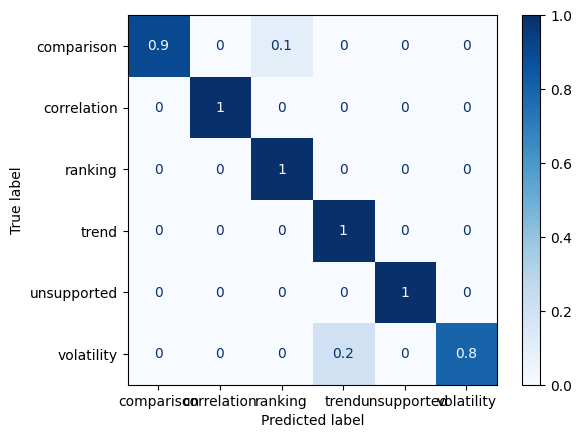

In [6]:
disp = ConfusionMatrixDisplay.from_estimator(
    fit_logr_pipeline,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    normalize="true",
)

plt.show()

In [ ]:

# save model for later use
joblib.dump(fit_logr_pipeline, '../data/log_regression_intent_classifier.joblib')

array(['ranking'], dtype=object)

In [ ]:
# inference
# Load from the saved file
loaded_model = joblib.load('../data/log_regression_intent_classifier.joblib')
# Make a prediction
unseen_question=["years with the highest unemployment rate since 2000"]
loaded_model.predict(unseen_question)